Topic/DATA:

This project is looking at data from chest x-ray images of patients who have been diagnosed with tuberculosis and some who have not. The data can be found here: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset

The original data has just over 750 pariticants and includes a metadata table that contains demographic information about each patient such as age and gender as well as wether or not they have TB, marked by 1 for having it and 0 not. Next, there is a mask image for each one. This is a plain white shape, smushed to highlight the patient's lungs. This is overlayed on the patients lung x-ray to make it easier to see. Each image has a unique identifier that links dircelty to its metadata data table entry.

The goal of this project is to create a convoluted nerual network(CNN) to try and predict wether or not a patient has tuberculosis based on thier chest x-rays making this a deep learning problem. This is important because often times a specialist has to be available to look at the images and help determine the diagnosis. This can be costly and inefficient, espeically in places susch as the emergency room where there are limited resources. It is important to note that something like this should likely not ever replace actual diagnosis, but may be used in emergencies or as supplemental material.

In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import cv2

EDA:

To begin, the chest x-rays, masks, and metadata need to be processed.

Starting with the metadata, since it will be the easiest to work with, let's take a look just to see what is going on.

In [ ]:

metadata_path = 'archive (1)/MetaData.csv'
metadata = pd.read_csv(metadata_path)
metadata = metadata.dropna()
print("\nDataset Overview:")
print(f"Total number of samples: {len(metadata)}")


Dataset Overview:
Total number of samples: 351


As we can see the total number of smaples is about half of the original size. I did this externally as the dataset was extremeley large, so I went into excel to delete half the meta data, and got rid of the corresponding masks and x-ray images. This was due to processing time and the strength of my poor computer. This cause there to be some missing rows which I removed.

In [34]:

metadata.head()

,id,gender,age,county,ptb,remarks
0,1000.0,male,31,Shenxhen,0.0,normal
1,1001.0,male,64,Shenxhen,0.0,normal
2,1002.0,male,35,Shenxhen,0.0,normal
3,1003.0,male,32,Shenxhen,1.0,"STB,ATB,tuberculosis pleuritis"
4,1004.0,male,2,Shenxhen,1.0,secondary PTB in the bilateral upper field


Here we can see what each column is and how it is setup. Importantly, I need to change the id from a float to an int as I will be referencing this column to process the images, but 1000.0 does not correspond correctly to an image because the image has the id 1000.

In [35]:
metadata['id'] = metadata['id'].astype(int)
metadata.head()

,id,gender,age,county,ptb,remarks
0,1000,male,31,Shenxhen,0.0,normal
1,1001,male,64,Shenxhen,0.0,normal
2,1002,male,35,Shenxhen,0.0,normal
3,1003,male,32,Shenxhen,1.0,"STB,ATB,tuberculosis pleuritis"
4,1004,male,2,Shenxhen,1.0,secondary PTB in the bilateral upper field


In [36]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 350
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       351 non-null    int64  
 1   gender   351 non-null    object 
 2   age      351 non-null    object 
 3   county   351 non-null    object 
 4   ptb      351 non-null    float64
 5   remarks  351 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 19.2+ KB


According to this summary, the metadata does not have any null values and appears to be extremley clean. Now we can get some basic statistics about the patients.

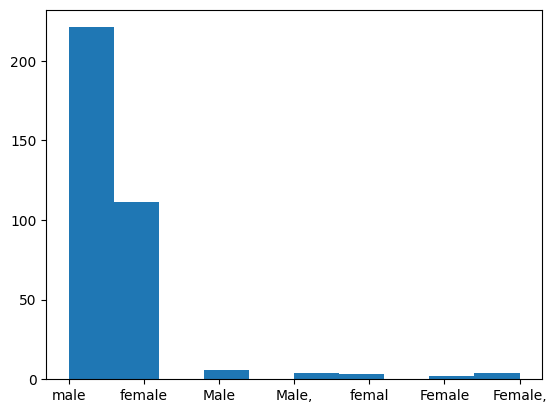

In [37]:
x = metadata['gender']

plt.hist(x)
plt.show() 

As we can see, there are some minor misspellings which can be easily fixed

In [38]:
metadata['gender'].unique()

array(['male', 'female', 'Male', 'Male,', 'femal', 'Female', 'Female,'],
      dtype=object)

In [39]:
metadata['gender'] = metadata['gender'].replace(to_replace=["Male", "Male,"], value="male")
metadata['gender'] = metadata['gender'].replace(to_replace=["femal", "Female","Female,"], value="female")
metadata['gender'].unique()

array(['male', 'female'], dtype=object)

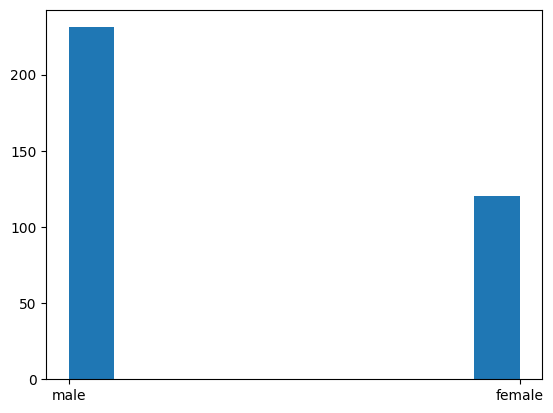

In [43]:
plt.hist(metadata['gender'])
plt.show() 

As we can see, there appear to be many more male patients than female, which is not a problem, just something to take note of. Importantly, we should recognize that because of this this model may not be as representaitve of the population due to the large gener gap.

Let's also take a look at the dsitribution of cases of TB.

In [45]:
metadata['ptb'].value_counts()

ptb
0.0    182
1.0    169
Name: count, dtype: int64

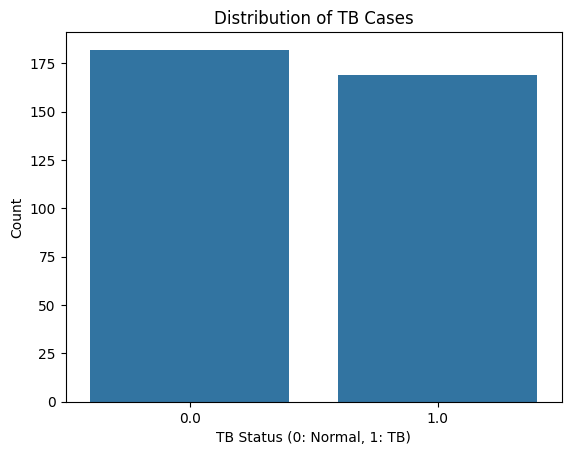

In [44]:
sns.countplot(data=metadata, x='ptb')
plt.title('Distribution of TB Cases')
plt.xlabel('TB Status (0: Normal, 1: TB)')
plt.ylabel('Count')
plt.show()

The amount of infected vs not is about even. Now to process the images I will use opencv, a common library for computer vision. I also resize the images as their original size is needlessly large. Fortunately, I can go row by row through the image folder based on the metadata id since they are in the same order as the id column

In [46]:
base_path = 'archive (1)/Chest-X-Ray/Chest-X-Ray/'

def load_and_preprocess_image(image_path, mask_path, image_size=(512, 512)):
    # Load and preprocess image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, image_size)
    img = img / 255.0
    
    # Load and preprocess mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, image_size)
    mask = mask / 255.0
    return img, mask

# Load all images and masks
images = []
masks = []
labels = []
for idx, row in metadata.iterrows():
    img_path = os.path.join(base_path, 'image', f"{row['id']}.png")
    mask_path = os.path.join(base_path, 'mask', f"{row['id']}.png")
    img, mask = load_and_preprocess_image(img_path, mask_path)
    images.append(img)
    masks.append(mask)
    labels.append(row['ptb'])

X_images = np.array(images)
X_masks = np.array(masks)
y = np.array(labels)

This has put the images into a numeric form we can use for the model and the computer can work with. Let's double check they were stored correctly

In [48]:
print(f"Images shape: {X_images.shape}")
print(f"Masks shape: {X_masks.shape}")
print(f"Labels shape: {y.shape}")
X_images[0]

Images shape: (351, 512, 512)
Masks shape: (351, 512, 512)
Labels shape: (351,)


array([[0.03529412, 0.03529412, 0.03529412, ..., 0.1254902 , 0.16078431,
        0.21176471],
       [0.03529412, 0.03529412, 0.03529412, ..., 0.1254902 , 0.15686275,
        0.21960784],
       [0.03529412, 0.03529412, 0.03529412, ..., 0.1254902 , 0.15686275,
        0.21568627],
       ...,
       [0.05490196, 0.05490196, 0.04705882, ..., 0.        , 1.        ,
        0.14509804],
       [0.0627451 , 0.05882353, 0.05882353, ..., 1.        , 0.14901961,
        0.15294118],
       [0.0745098 , 0.0745098 , 0.0745098 , ..., 0.1372549 , 0.14901961,
        0.17254902]])

This is a demostration of the original x-ray with the mask overlayed on it. As you can see the mask overlaying the lungs make it much clearer if there is an infection.

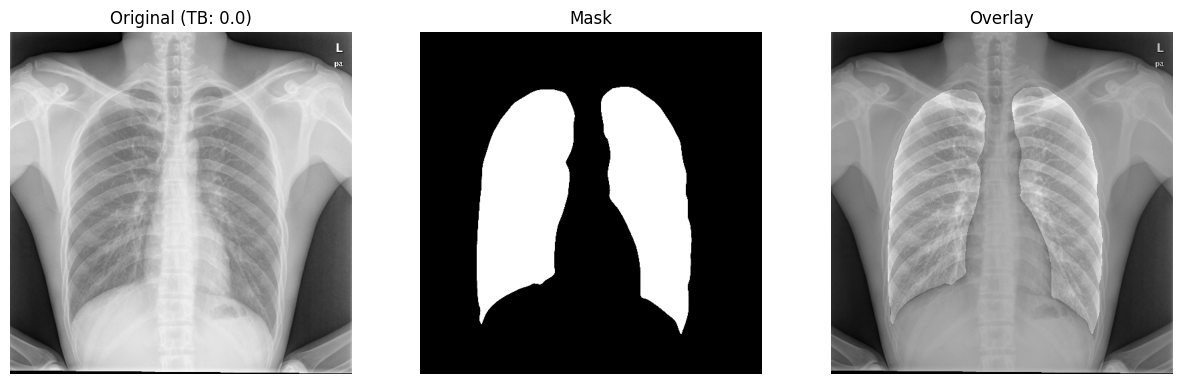

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5*2))

idx = np.random.randint(len(X_images))
        
    # Original image
axes[0].imshow(X_images[idx], cmap='gray')
axes[0].set_title(f'Original (TB: {y[idx]})')
axes[0].axis('off')
        
    # Mask
axes[1].imshow(X_masks[idx], cmap='gray')
axes[1].set_title('Mask')
axes[1].axis('off')
        
    # Overlay
overlay = X_images[idx].squeeze().copy()
overlay[X_masks[idx].squeeze() > 0.5] *= 1.5
axes[2].imshow(overlay, cmap='gray')
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.show()


Model Creation:

Now that the images are processed we can start to create the model. To start I am splitting the data into several sets of test, train and validation data. We use the train data to train the actual model and compare the model's effectiveness with the test data. We need the validation data as well because the CNN uses it to tune the model on each of its iterations. Additoanlly, I changed the y values from floats to ints just for consistency.

In [12]:
X_train_val, X_test, X_mask_train_val, X_mask_test, y_train_val, y_test = train_test_split(
    X_images, X_masks, y, 
    test_size=0.3, 
    stratify=y, 
    random_state=42
)
y_train_val = y_train_val.astype(int)
y_test = y_test.astype(int)
X_train, X_val, X_mask_train, X_mask_val, y_train, y_val = train_test_split(
    X_train_val, X_mask_train_val, y_train_val,
    test_size=0.3,
    stratify=y_train_val,
    random_state=42
)


Now we are creating the CNN model. As you can see I have a total of 6 blocks as I wanted to include both the x-rays themsevels along with their masks in the model. I did some further research to try and find similar models as this is a new and difficult area for me. Based on this there are 2 "branches" one for the x-ray and one for the mask each with 3 convolution layers and utilize batch normalization and pooling. These branches then combine to create one overlay layer. Lastly, there is a dense layer as at this point in the network the less "primitive" features have likely been extracted, so having more neurons will help "represent" more abstract features and hopefully help in accuracy. I also switch to average pooling rather than max pooling to focus on a wider variety of features. Finally, I am using binary cross entropy for the loss function since this task is binary (either  you have TB or you do not) and using the area under the curve or AUC as the metric as opposed to ROC since I have used that many times in the past.

Before training the model I include typical callbacks in order to stop the nerual network from training if there are not significant improvements being made.

THE MODEL FITTING TAKES A LONG TIME TO RUN I WOULD NOT RECCOMEND RUNNING IT

I also want to note here the reasoning for choosing the CNN model. It is well known that the CNN model is great for looking at images. Other neural network type models such as reccurent neural networks privvy themselves to data that is sequential like text and are often used in language processing. Additionally, CNN models have been used in all kinds of image classification already, including medical images such as MRI scans. I also felt that including one complex model would suffice as oppsed to having two or more models. Also due to the computing power needed for this model it would not feasiable to cosntruct a second neural network type model to compare it to.

In [ ]:
def create_model(input_shape=(512, 512, 1)):
    # Image input branch
    img_input = layers.Input(shape=input_shape)
    
    # First block
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(img_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x) 
    
    # Second block
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)  
    
    # Third block
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)  
    
    # Mask input branch
    mask_input = layers.Input(shape=input_shape)
    
    # First block - mask
    y = layers.Conv2D(32, 3, activation='relu', padding='same')(mask_input)
    y = layers.BatchNormalization()(y)
    y = layers.MaxPooling2D()(y)  
    
    # Second block - mask
    y = layers.Conv2D(64, 3, activation='relu', padding='same')(y)
    y = layers.BatchNormalization()(y)
    y = layers.MaxPooling2D()(y)  
    
    # Third block - mask
    y = layers.Conv2D(128, 3, activation='relu', padding='same')(y)
    y = layers.BatchNormalization()(y)
    y = layers.MaxPooling2D()(y)  
    
    #Overlay
    concat = layers.concatenate([x, y])
    z = layers.Conv2D(256, 3, activation='relu', padding='same')(concat)
    z = layers.BatchNormalization()(z)
    z = layers.GlobalAveragePooling2D()(z)
    
    # Dense layers
    z = layers.Dense(128, activation='relu')(z)
    z = layers.Dropout(0.5)(z)
    output = layers.Dense(1, activation='sigmoid')(z)
    
    # Create and compile model
    model = models.Model(inputs=[img_input, mask_input], outputs=output)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()]
    )
    
    return model

# Create and display model
model = create_model()
print("\nModel Summary:")
print(model.summary())


Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 512, 512,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]  

 Total params: 811,265 (3.09 MB)

 Trainable params: 809,857 (3.09 MB)

 Non-trainable params: 1,408 (5.50 KB)

None


In [ ]:
callbacks = [
    ModelCheckpoint(
        'best_model.keras',  
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=10,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.1,
        patience=5,
        verbose=1
    )
]

The number of epochs and the batch size were chosen aribtraily, but refelct the number of samples I have and common best practices for CNN.

In [19]:
model1 = model.fit(
    [X_train, X_mask_train],
    y_train,
    validation_data=([X_val, X_mask_val], y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1  # Added verbose=1 to show training progress
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.7342 - auc: 0.7862 - loss: 0.5854 
Epoch 1: val_auc improved from -inf to 0.71345, saving model to best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 143s 20s/step - accuracy: 0.7371 - auc: 0.7869 - loss: 0.5814 - val_accuracy: 0.5000 - val_auc: 0.7135 - val_loss: 0.6842 - learning_rate: 0.0010
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8020 - auc: 0.8721 - loss: 0.4667 
Epoch 2: val_auc did not improve from 0.71345
6/6 ━━━━━━━━━━━━━━━━━━━━ 131s 20s/step - accuracy: 0.8010 - auc: 0.8703 - loss: 0.4671 - val_accuracy: 0.5135 - val_auc: 0.6981 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8005 - auc: 0.8688 - loss: 0.4522 
Epoch 3: val_auc did not improve from 0.71345
6/6 ━━━━━━━━━━━━━━━━━━━━ 96s 14s/step - accuracy: 0.7998 - auc: 0.8673 - loss: 0.4554 - val_accuracy: 0.5135 - val_auc: 0.6948 - val_loss: 0.7675 - learning_rate: 0.0010
Epoch 4/10
6/6 ━━━━━━━━━

Results:

As we can see the accuracy did not rise much above 50%, so let's see if we can see what is going on by looking at some graphs.

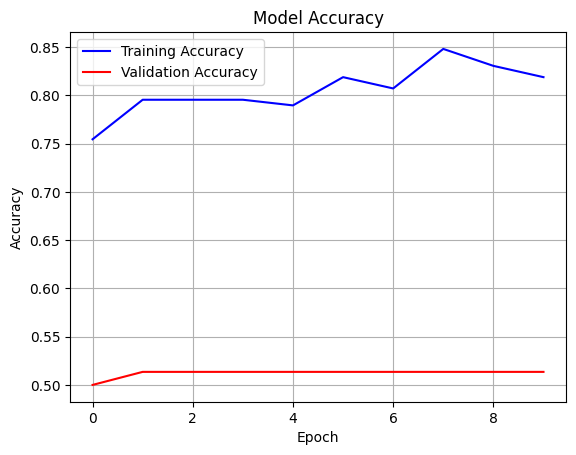

In [20]:
plt.plot(model1.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(model1.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

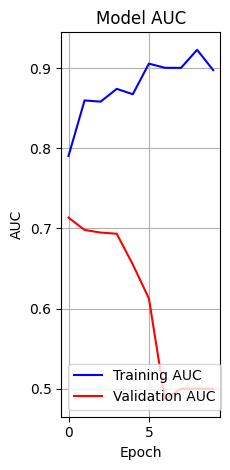

In [55]:
plt.subplot(1, 3, 3)
plt.plot(model1.history['auc'], label='Training AUC', color='blue')  # Changed from 'auc' to 'auc_1'
plt.plot(model1.history['val_auc'], label='Validation AUC', color='red')  # Changed from 'val_auc' to 'val_auc_1'
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [57]:
y_pred = model.predict([X_test, X_mask_test])
y_pred_binary = (y_pred > 0.5).astype(int)
list(y_pred_binary)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


[array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),

As we can see, for some reasson, the final model is prediciting everything to be non-TB, which is odd as the first iteration had an accuracy of about 71%. Although it is not shown in this notebook, due to limited space and time, I did first attempt to change the batch size and number of epochs to different numbers, but came up with similar results after that parameter tuning. 

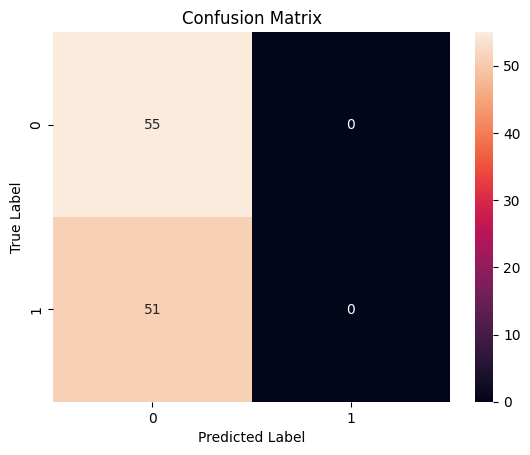

In [67]:
cm = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Conclusion:

Although this model did not achieve the main goal, I do beleive it is possible in the future! I did some research in to the particular problem I was having and have come to the consensus that there is likely not enough data for the amount of layers I have created in the nueral network. The reasoning behind this was discussed a bit earlier, but my computer was having a hard time trying to use all 700+ images. This  uneveness is causing overfitting to occur very rapidly in the model training process, and causing the model to almost "memorize" the training data, but do very poorly on new data. This would account for the training AUC going up while the validation accuracy plummets. To improve this mode, the easiest first step would be to increase the number of images inlcuded in the dataset and see if that produces better results. Second, would to be rework the neural network model to include less layers. I would also like to see if the mask layer actually adds anything to the model. Masks in practice are used so that people can see abnormalities in the lungs better, but a computer may not need the extra help. So I wonder if you would be bale to remove the masks from the model altogether and still get good results.